In [1]:
# Importing Necessary Libraries
# For Data Manipulation
import numpy as np 
import pandas as pd 

#For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Train - Test Split
from sklearn.model_selection import train_test_split,cross_val_score

# For Data Preprocessing
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer 

# For Machine Learning
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# For Evaluation
from sklearn.metrics import classification_report, roc_auc_score 

# For Dealing with Imbalance Data
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE  

In [2]:
# Loading the Dataset
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head() 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Getting Basic Information
print("Shape : ", df.shape)
df.info()
df.describe()

Shape :  (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
# Finding Null Values per Column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# Data Cleaning 
# Convert data to numeric ,if it can't be converted so pythin doesn't gives error
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
# Removing rows with null values
df=df.dropna()

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


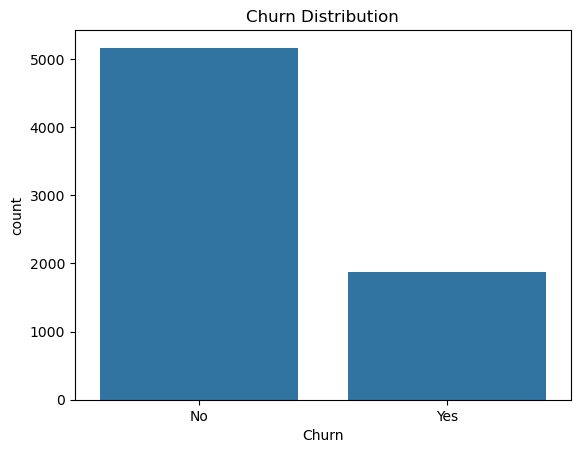

In [6]:
# Exploratory Data Analysis
# Calculating Number of 1 and 0 in Churn column 
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

# Plotting it in form of boxplot for better visualization
sns.countplot(x="Churn",data=df)
plt.title("Churn Distribution")
plt.show()

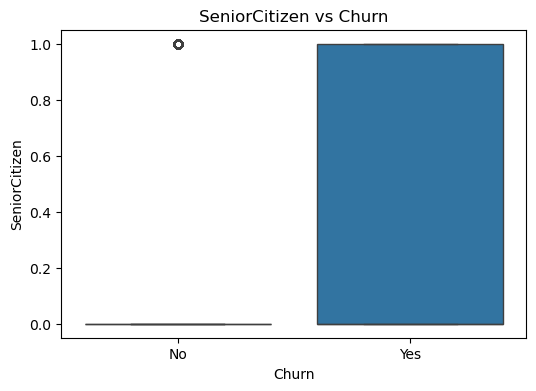

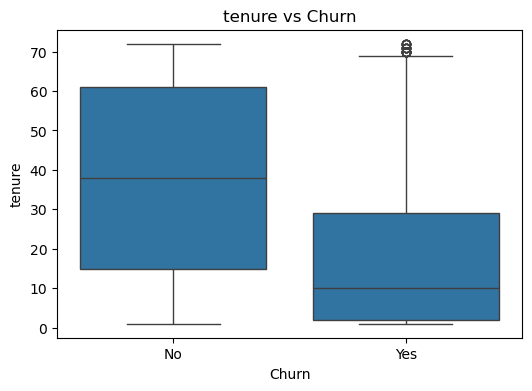

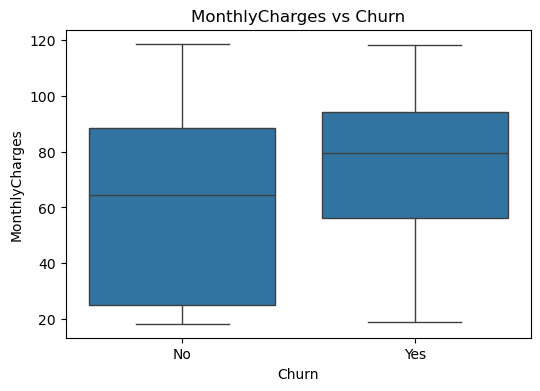

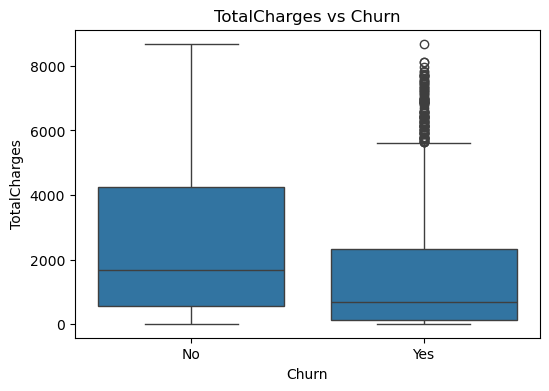

In [7]:
# Finding relationship between different columns and churn
num_cols=[cols for cols in df.columns if df[cols].dtype in ['int64','float64']]

for col in num_cols : 
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn',y=col,data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

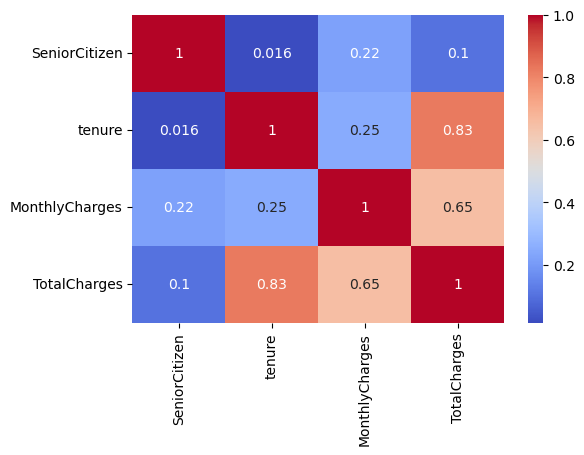

In [8]:
# Plotting Correlation Graph to check how each feature is correlated with each otherj
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [9]:
# As model know numbers so converting No to 0 and Yes to 1
df["Churn"]=df["Churn"].map({"No":0,"Yes":1})
df=df.drop("customerID",axis=1)

In [10]:
# Removing target column to get two 
x=df.drop("Churn",axis=1)
y=df["Churn"]

In [11]:
# Train - Test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [12]:
# Finding numerical columns and categorical columns
num_cols=x.select_dtypes(include=["int64","float64"]).columns
cat_cols=x.select_dtypes(include=["object"]).columns
# Defining column transformer
preprocessor=ColumnTransformer(transformers=[("num",StandardScaler(),num_cols),("cat",OneHotEncoder(drop="first"),cat_cols)])

In [13]:
# Defing a dictionary for different models
# Using different modelss to compare each other
# Using the one with best score
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":XGBClassifier(eval_metric="logloss",random_state=42)
}

In [14]:
# Storing result of each modelon the dataset.
# Will choose the best model
# Using imbpipeline 
# Since data is highly unbalanced so we are going to create synthetic data of minoruty class
results={}
for name, model in models.items():
    pipeline=ImbPipeline(steps=[("preprocess",preprocessor),
                                ("smote",SMOTE(random_state=42)),
                                ("model",model)
                               ])
    scores=cross_val_score(pipeline,x_train,y_train,cv=5,scoring="roc_auc",n_jobs=-1)
    results[name]=scores.mean()
    print(f"{name} CV ROC-AUC:{scores.mean():.4f}")

Logistic Regression CV ROC-AUC:0.8447
Random Forest CV ROC-AUC:0.8240
XGBoost CV ROC-AUC:0.8232


In [15]:
# Storing the result in form of dataframe
results_df=pd.DataFrame.from_dict(results,orient="index",columns=["CV_ROC_AUC"]).sort_values(by="CV_ROC_AUC",ascending=False)

print(results_df)

                     CV_ROC_AUC
Logistic Regression    0.844706
Random Forest          0.824023
XGBoost                0.823213


In [16]:
# Since Logistic Regression is the best performer, we are going to use it
# All have a near score 
# But best is of logistic
best_pipeline=ImbPipeline(
    steps=[("preprocess",preprocessor),
           ("smote",SMOTE(random_state=42)),
           ("model",LogisticRegression(max_iter=1000))]
)

In [17]:
# Using GRIDSeacrhCV to tune hyperparameter
from sklearn.model_selection import GridSearchCV

In [18]:
# Defining the parameter grid
param_grid={"model__C":[0.01,0.1,1,10],"model__penalty":["l1","l2"],"model__solver":["liblinear"],"model__class_weight":[None,"balanced"]}

In [19]:
# Finding the best
grid=GridSearchCV(best_pipeline,param_grid,cv=5,scoring="roc_auc",n_jobs=-1)
grid.fit(x_train,y_train)

print("Best Params :",grid.best_params_)
print("Best ROC-AUC:",grid.best_score_)

Best Params : {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best ROC-AUC: 0.8450253872877307


In [20]:
# Saving the best grid
best_model=grid.best_estimator_

y_pred=best_model.predict(x_test)
y_prob=best_model.predict_proba(x_test)[:,1]

print(classification_report(y_test,y_pred))
print("Test ROC-AUC:",roc_auc_score(y_test,y_prob))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

Test ROC-AUC: 0.8344937904757961


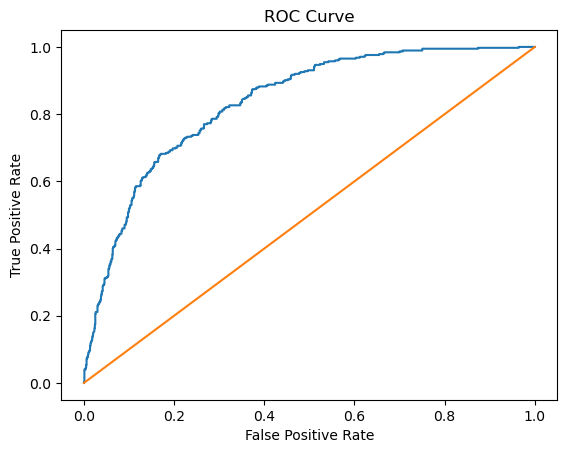

In [21]:
# Plotting roc - auc curve
from sklearn.metrics import roc_curve
fpr, tpr, _ =roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [22]:
# Finding the importance of each feature by seeing thier coefficient, the one with higher abs | coefficient | has higher importance in prediction
feature_names=best_model.named_steps["preprocess"].get_feature_names_out()
coefficients=best_model.named_steps["model"].coef_[0]
importance=pd.DataFrame({"Feature":feature_names,"Coefficient":coefficients})
importance["AbsCoef"]=importance["Coefficient"].abs()
importance=importance.sort_values("AbsCoef",ascending=False)

importance.head(15)

,Feature,Coefficient,AbsCoef
25,cat__Contract_Two year,-1.348318,1.348318
1,num__tenure,-1.167136,1.167136
24,cat__Contract_One year,-0.818371,0.818371
10,cat__InternetService_Fiber optic,0.619406,0.619406
13,cat__OnlineSecurity_Yes,-0.592262,0.592262
19,cat__TechSupport_Yes,-0.488163,0.488163
3,num__TotalCharges,0.477994,0.477994
7,cat__PhoneService_Yes,-0.457944,0.457944
28,cat__PaymentMethod_Electronic check,0.380985,0.380985
6,cat__Dependents_Yes,-0.340233,0.340233


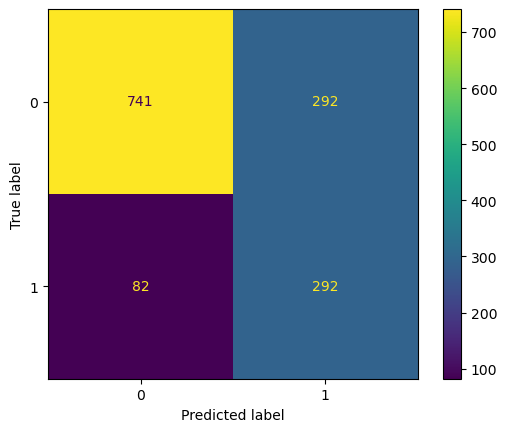

In [23]:
# Plotting Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model,x_test,y_test)
plt.show()

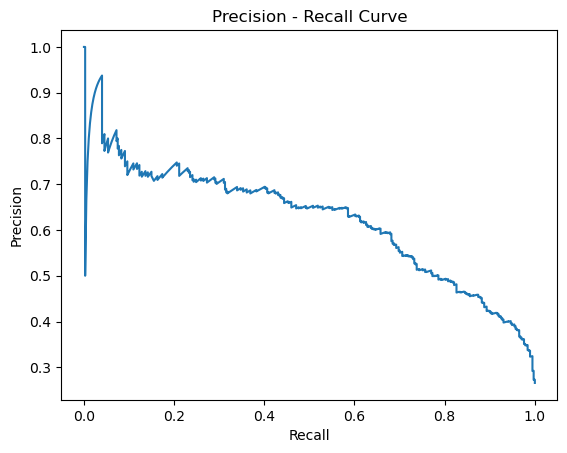

In [24]:
# Plotting precision - recall curve
from sklearn.metrics import precision_recall_curve

precision,recall,_=precision_recall_curve(y_test,y_prob)

plt.plot(recall,precision)
plt.title("Precision - Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [25]:
# Saving our model 
import joblib
joblib.dump(best_model,"churn_model.pkl")

['churn_model.pkl']